# 2023 NBA player anomaly detection

## 1. Introduction

In this project, we aim to identify statistically unusual player performance profiles in the 2023 NBA dataset using machine learning–based anomaly detection techniques.

Traditional univariate outlier detection methods (such as IQR) often fail when anomalies arise from rare combinations of multiple features rather than extreme values in a single variable.

To address this issue, we apply: Isolation Forest Local Outlier Factor (LOF)

We then use Explainable AI techniques (SHAP and LIME) and surrogate classifiers to interpret which variables contribute most to anomaly detection.

## 2. Dataset
The dataset contains performance statistics for NBA players in the 2023 season.

Variables used

* age
* minutes_played_per_game
* rebounds_per_game
* assists_per_game
* points_per_game

Player names were removed during modeling and used later for interpretation.

## 3. Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

In [8]:
data = pd.read_csv('nba_players_2023.csv')
data.head()
data = data.drop('name',axis=1)
logdata = np.log1p(data)

### 3.1 Distribution Shape
* QQ plot (raw variables)
* heavy tail observation


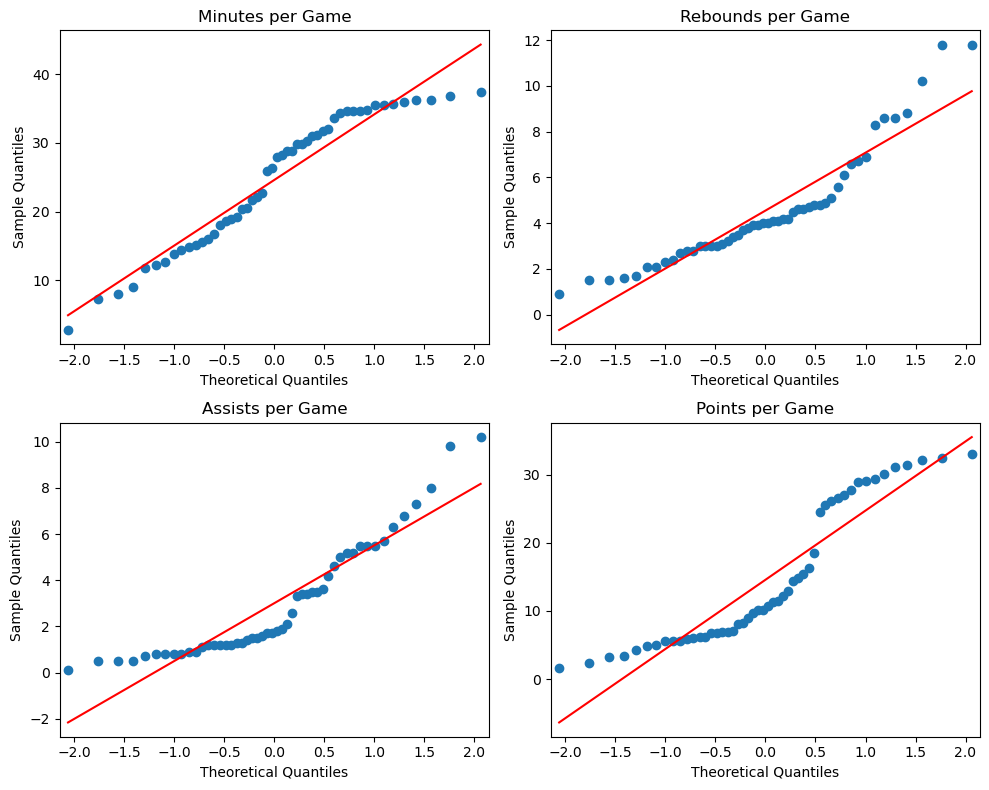

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

qqplot(data['minutes_played_per_game'].dropna(), line='s', ax=axs[0, 0])
axs[0, 0].set_title('Minutes per Game')

qqplot(data['rebounds_per_game'].dropna(), line='s', ax=axs[0, 1])
axs[0, 1].set_title('Rebounds per Game')

qqplot(data['assists_per_game'].dropna(), line='s', ax=axs[1, 0])
axs[1, 0].set_title('Assists per Game')

qqplot(data['points_per_game'].dropna(), line='s', ax=axs[1, 1])
axs[1, 1].set_title('Points per Game')

plt.tight_layout()
plt.show()

### 3.2 Log Transformation Check
* log1p transformation
* QQ plot after transformation
* skewness reduction discussion

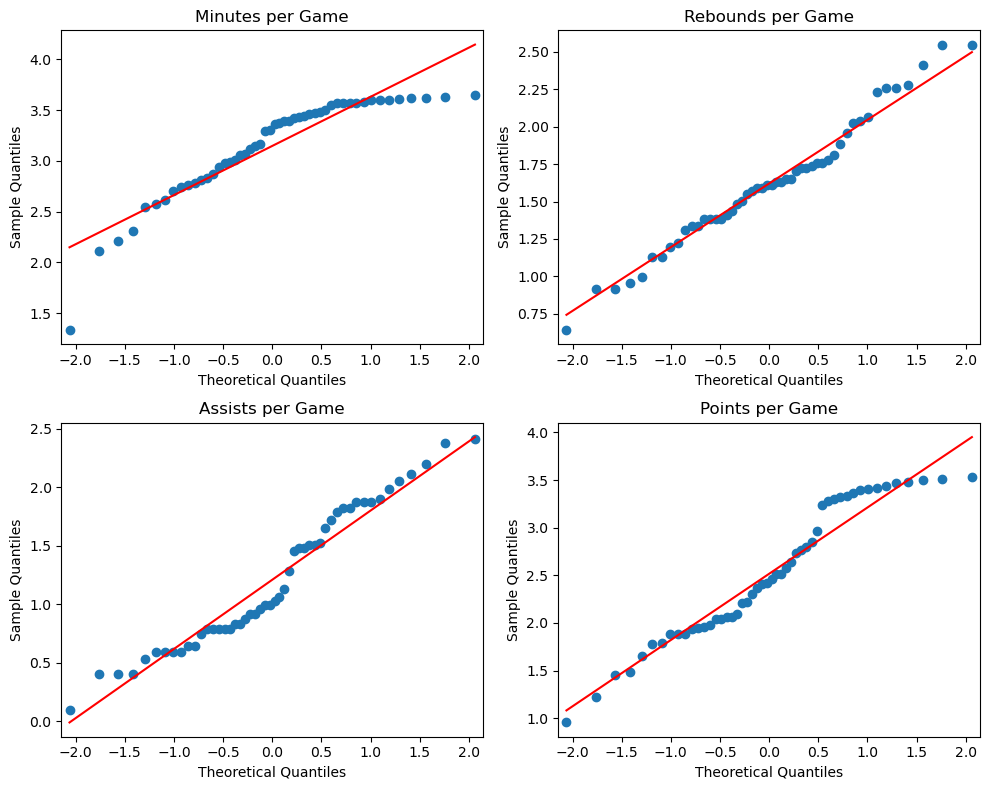

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

qqplot(logdata['minutes_played_per_game'].dropna(), line='s', ax=axs[0, 0])
axs[0, 0].set_title('Minutes per Game')

qqplot(logdata['rebounds_per_game'].dropna(), line='s', ax=axs[0, 1])
axs[0, 1].set_title('Rebounds per Game')

qqplot(logdata['assists_per_game'].dropna(), line='s', ax=axs[1, 0])
axs[1, 0].set_title('Assists per Game')

qqplot(logdata['points_per_game'].dropna(), line='s', ax=axs[1, 1])
axs[1, 1].set_title('Points per Game')

plt.tight_layout()
plt.show()

Based on the Q–Q plots, the empirical distributions deviate noticeably from the reference line, indicating that the variables do not follow a normal distribution. In particular, the upper tails show clear departures from normality, suggesting the presence of right-skewed distributions and heavy-tailed behavior. This implies that extreme values may occur more frequently than expected under a normal distribution.

After applying a log1p transformation, the distributions appear closer to the reference line, indicating that the skewness has been partially reduced. However, some deviations from normality remain, suggesting that unusual observations may still exist and therefore require further investigation using anomaly detection methods.

### 3.3 Multiclinearity

In [36]:
df = pd.read_csv('nba_players_2023.csv')
X = df.drop(columns=['name']).select_dtypes(include='number')
corr = X.corr(method='pearson')
print(corr)

                              age  minutes_played_per_game  rebounds_per_game  \
age                      1.000000                 0.167784           0.171542   
minutes_played_per_game  0.167784                 1.000000           0.637562   
rebounds_per_game        0.171542                 0.637562           1.000000   
assists_per_game         0.262016                 0.736755           0.539482   
points_per_game          0.245789                 0.886774           0.728824   

                         assists_per_game  points_per_game  
age                              0.262016         0.245789  
minutes_played_per_game          0.736755         0.886774  
rebounds_per_game                0.539482         0.728824  
assists_per_game                 1.000000         0.815405  
points_per_game                  0.815405         1.000000  


## 4. Limitations of Univariate Outlier Detection

### 4.1 IQR-Based Detection
The IQR rule identifies outliers using:

* Lower = Q1 − 2.5 × IQR
* Upper = Q3 + 2.5 × IQR
  
Each feature was tested independently

### 4.2 Why IQR Fails

In [103]:
xvar = ['minutes_played_per_game','rebounds_per_game','assists_per_game','points_per_game']
factor = 2.5

iqr_flags = {}

for col in xvar:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    flag = (data[col] < lower) | (data[col] > upper)
    iqr_flags[col] = flag

    print(col, flag.sum())

minutes_played_per_game 0
rebounds_per_game 3
assists_per_game 0
points_per_game 0


The IQR approach fails because:
* It examines each feature individually
* Basketball performance is multidimensional
  
Example:
A player may not be extreme in points, rebounds, or assists individually but may still be rare due to their combined statistical profile.

## 5. Multivariate Anomaly Detection

### 5.1 Isolation Forest

Isolation Forest detects anomalies by isolating data points through random feature splits.
Characteristics:
* Efficient for high-dimensional data
* Detects points located in sparse regions of the feature space
  
The model identified several players as anomalies.

In [29]:
import pandas as pd
from sklearn.ensemble import IsolationForest

np.random.seed(123)

names = df['name']
X = df.drop(columns=['name']).select_dtypes(include='number')

iso = IsolationForest(contamination=0.1, random_state=42)
pred = iso.fit_predict(X)

anomaly_idx = X.index[pred == -1]
anomaly_players = names.loc[anomaly_idx]

print("Anomalies:")
for name in anomaly_players:
    print(name)

Anomalies:
Damian Lillard
Giannis Antetokounmpo
LeBron James
Nikola Jokić
Tony Bradley


### 5.2 Local Outlier Factor (LOF)

LOF measures how isolated a data point is relative to its neighbors. Unlike Isolation Forest, LOF focuses on local density differences.
Both methods produced similar anomaly players.

In [28]:
from pyod.models.lof import LOF
data = pd.read_csv('nba_players_2023.csv')

X = data.drop('name', axis=1)
Y = data["name"]

data.describe()
lof = LOF(contamination=0.1, n_neighbors=20, n_jobs=-1)
lof.fit(X)
is_outlier = lof.labels_ == 1
outliers = data[is_outlier]
print(outliers)

              name  age  minutes_played_per_game  rebounds_per_game  \
1   Damian Lillard   32                     36.3                4.8   
13     Joel Embiid   28                     34.6               10.2   
17    LeBron James   38                     35.5                8.3   
18     Luka Dončić   23                     36.2                8.6   
23    Tony Bradley   25                      2.8                0.9   

    assists_per_game  points_per_game  
1                7.3             32.2  
13               4.2             33.1  
17               6.8             28.9  
18               8.0             32.4  
23               0.1              1.6  


## 6. Explanable AI Analysis

To understand why these players were detected as anomalies, we trained surrogate models.

### 6.1 Surrogate Models

Isolation Forest produces anomaly labels. 

These labels were used as targets to train:
* Decision Tree
* Logistic Regression
* Random Forest
* Neural Network
  
These models approximate the decision boundary of the anomaly detector.


### 6.2 Logistic Regression Feature Importance

In [43]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

df = pd.read_csv('nba_players_2023.csv')

names = df['name']
X = df.drop(columns=['name']).select_dtypes(include='number')

X_train, X_test, names_train, names_test = train_test_split(
    X, names, test_size=0.2, random_state=42
)

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)

train_pred = iso.predict(X_train)
test_pred = iso.predict(X_test)

train_anomaly_players = names_train[train_pred == -1]

y_train = (train_pred == -1).astype(int)
y_test = (test_pred == -1).astype(int)

print("Train anomalies:")
for name in train_anomaly_players:
    print(name)

Train anomalies:
Giannis Antetokounmpo
Tony Bradley
Luka Dončić
Nikola Jokić


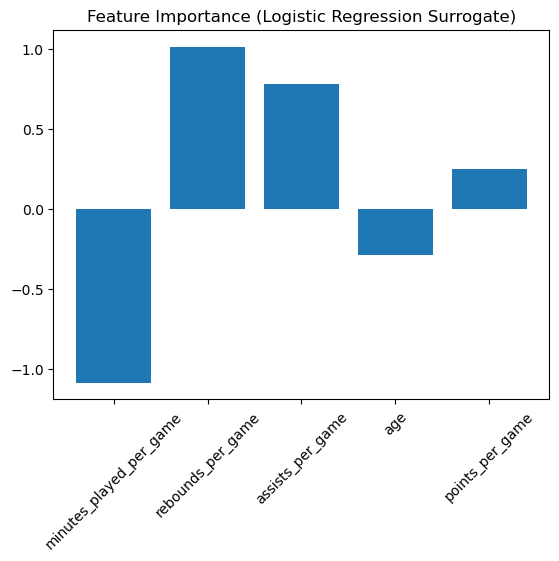

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

coef = log_reg.coef_[0]

import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': coef
}).sort_values(by='coef', key=abs, ascending=False)


plt.bar(coef_df['feature'], coef_df['coef'])
plt.xticks(rotation=45)
plt.title('Feature Importance (Logistic Regression Surrogate)')
plt.show()

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy of Decision Tree: {acc}")

Accuracy of Decision Tree: 0.9


In [48]:
from sklearn.tree import export_text
rules = export_text(model, feature_names=list(X_train.columns))
print(rules)

|--- rebounds_per_game <= 10.30
|   |--- points_per_game <= 2.00
|   |   |--- class: 1
|   |--- points_per_game >  2.00
|   |   |--- points_per_game <= 32.30
|   |   |   |--- class: 0
|   |   |--- points_per_game >  32.30
|   |   |   |--- class: 1
|--- rebounds_per_game >  10.30
|   |--- class: 1



[0.017224   0.15197176 0.37684056 0.25749975 0.19646393]


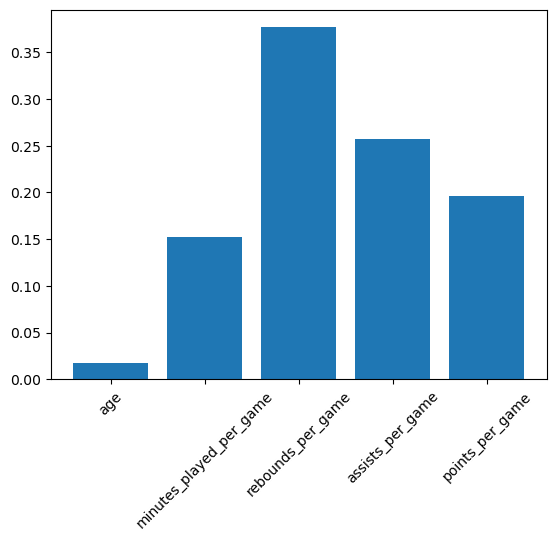

In [49]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_
feature_names = X_train.columns
print(feature_importances)

plt.bar(feature_names, feature_importances)
plt.xticks(rotation=45)
plt.show()

[0.005  0.1675 0.0175 0.0125 0.1825]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


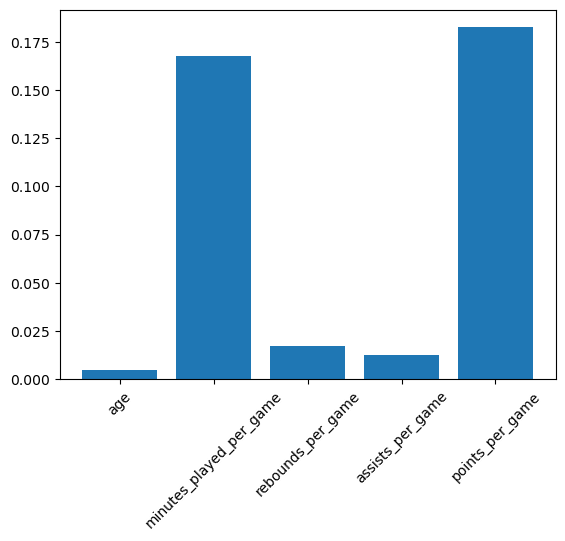

In [110]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(10,10))
model.fit(X_train, y_train)
from sklearn.inspection import permutation_importance
result = permutation_importance(model,X_train, y_train,n_repeats=10,random_state=42,scoring='accuracy')
print(result.importances_mean)

import matplotlib.pyplot as plt
plt.bar(X_train.columns,result.importances_mean)
plt.xticks(rotation=45)
plt.show()


(5, 2)


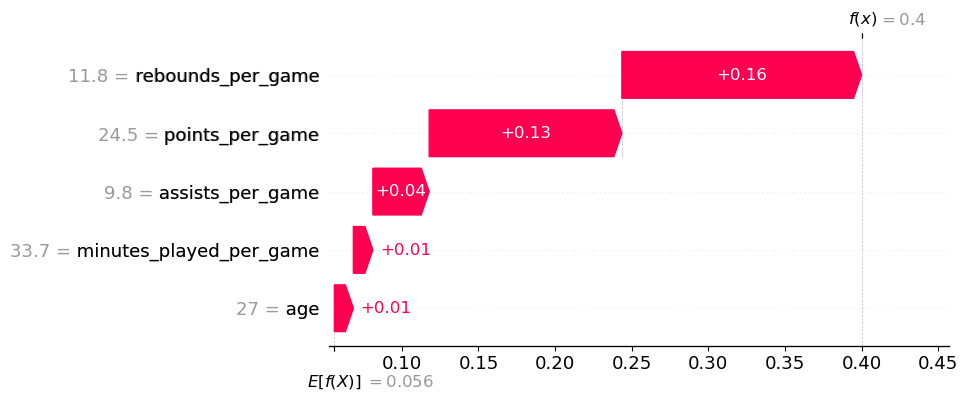

In [111]:
import shap
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
explainer = shap.KernelExplainer(knn.predict_proba, shap.kmeans(X, 10))
test_instance = X.iloc[20]
shap_values = explainer.shap_values(test_instance)
print(shap_values.shape)

shap.waterfall_plot(shap.Explanation(values=shap_values[:,1],
                                     base_values=explainer.expected_value[1],
                                     data=test_instance,
                                     feature_names=X.columns))

(5, 2)


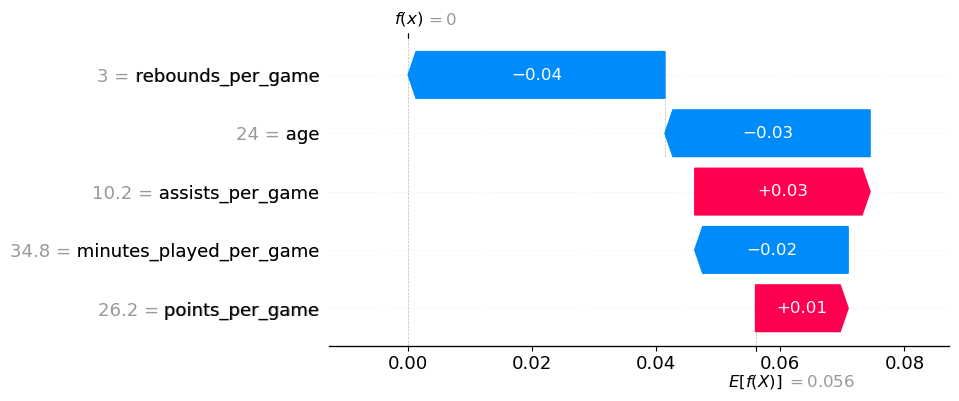

In [112]:
test_instance = X.iloc[24]
shap_values = explainer.shap_values(test_instance)
print(shap_values.shape)

shap.waterfall_plot(shap.Explanation(values=shap_values[:,1],
                                     base_values=explainer.expected_value[1],
                                     data=test_instance,
                                     feature_names=X.columns))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


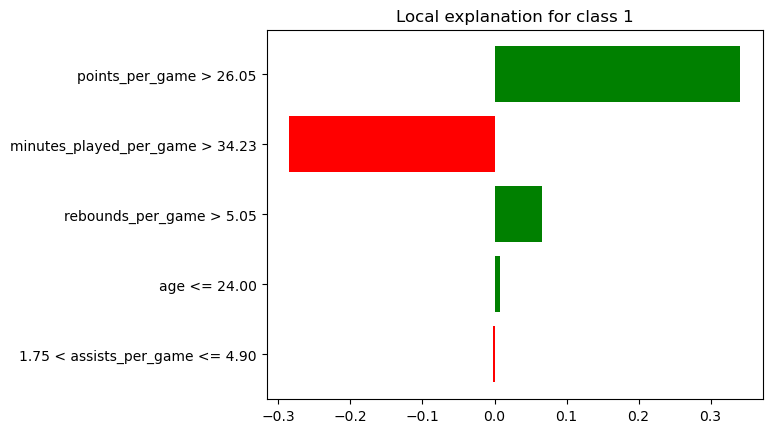

In [113]:
from lime.lime_tabular import LimeTabularExplainer
instance = X.iloc[10]
explainer = LimeTabularExplainer(  X.values,  feature_names=X.columns,  mode='classification')
exp = explainer.explain_instance(  instance.values,  model.predict_proba)
exp.as_pyplot_figure()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


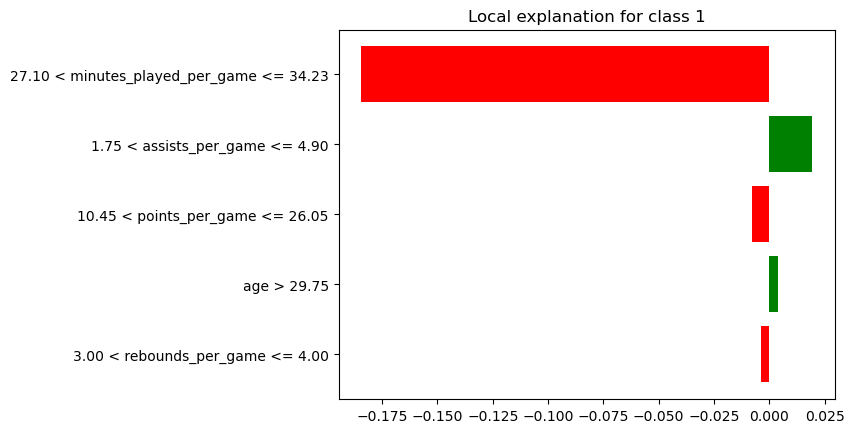

In [114]:
from lime.lime_tabular import LimeTabularExplainer
instance = X.iloc[33]
explainer = LimeTabularExplainer(  X.values,  feature_names=X.columns,  mode='classification')
exp = explainer.explain_instance(  instance.values,  model.predict_proba)
exp.as_pyplot_figure()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


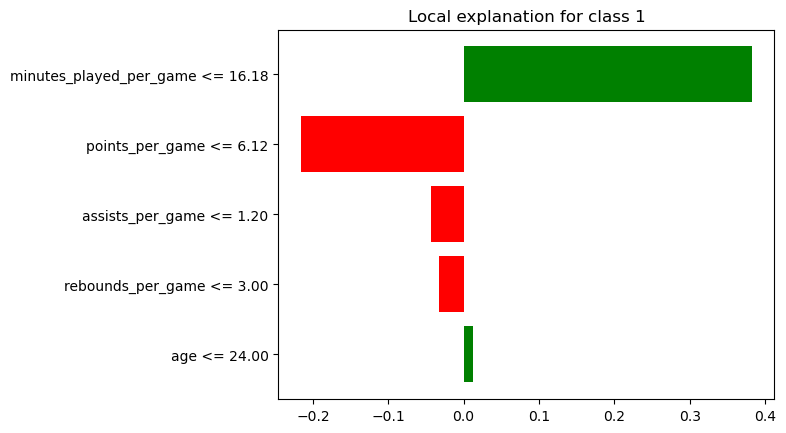

In [115]:
from lime.lime_tabular import LimeTabularExplainer
instance = X.iloc[14]
explainer = LimeTabularExplainer(  X.values,  feature_names=X.columns,  mode='classification')
exp = explainer.explain_instance(  instance.values,  model.predict_proba)
exp.as_pyplot_figure()
plt.show()

In [116]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2).fit(X)
original_clusters = kmeans.predict(X)

for i in range(X.shape[1]):
  X_reduced = np.delete(X, i, axis=1)
  reduced_clusters = kmeans.fit_predict(X_reduced)
  importance = 1 - adjusted_rand_score(original_clusters, reduced_clusters)
  print(f'{X.columns[i]}: {importance}')


age: 0.15692554043234586
minutes_played_per_game: 0.23218066337332388
rebounds_per_game: 0.0
assists_per_game: 0.367043398012872
points_per_game: 0.60195117274111


## Further Investigation

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from pyod.models.lof import LOF
from pyod.models.iforest import IForest

In [118]:
#Detecting anomaly by using IForest
data = pd.read_csv('nba_players_2023.csv')
X = data.drop('name', axis=1)
iforest = IForest(n_estimators=100,contamination=0.05,n_jobs=-1)
fit = iforest.fit(X)
labels = fit.predict(X)
data[labels == 1]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


,name,age,minutes_played_per_game,rebounds_per_game,assists_per_game,points_per_game
6,Giannis Antetokounmpo,28,32.1,11.8,5.7,31.1
20,Nikola Jokić,27,33.7,11.8,9.8,24.5
23,Tony Bradley,25,2.8,0.9,0.1,1.6


To examine the robustness of our findings, we evaluated multiple threshold values (0.10 and 0.05).
While the number of identified anomalous players varied, the key contributing variables—particularly rebounds—remained consistent across thresholds.

In [119]:
#Detecting anomaly by using LOF
data = pd.read_csv('nba_players_2023.csv')
X = data.drop('name', axis=1)
Y = data["name"]
data.describe()
lof = LOF(contamination=0.05, n_neighbors=20, n_jobs=-1)
lof.fit(X)
is_outlier = lof.labels_ == 1
outliers = data[is_outlier]
print(outliers)

              name  age  minutes_played_per_game  rebounds_per_game  \
1   Damian Lillard   32                     36.3                4.8   
17    LeBron James   38                     35.5                8.3   
23    Tony Bradley   25                      2.8                0.9   

    assists_per_game  points_per_game  
1                7.3             32.2  
17               6.8             28.9  
23               0.1              1.6  


From these two tests, we can obtain three anomalies respectively while **Lebron** and **Tony** are duplicated. We can explain these four anomalies by common sense: **LeBron** ,**Damian** and **Jokic** have *obviously excellent performances on different aspects* with *long playing time* while **Tony** has an *bad performance on all aspects* with *short playing time*

In [120]:
#Surrogate Classifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X)
y = (iso.predict(X) == -1).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
anomaly = X_train[y_train == 1].index
anomaly_player = Y.loc[anomaly]
print("Anomalies:")
for name in anomaly_player:
    print(name)

Anomalies:
Tony Bradley
Nikola Jokić


[[ 0.49571809 -0.21038496  0.51850091  0.58300239  0.13548365]]


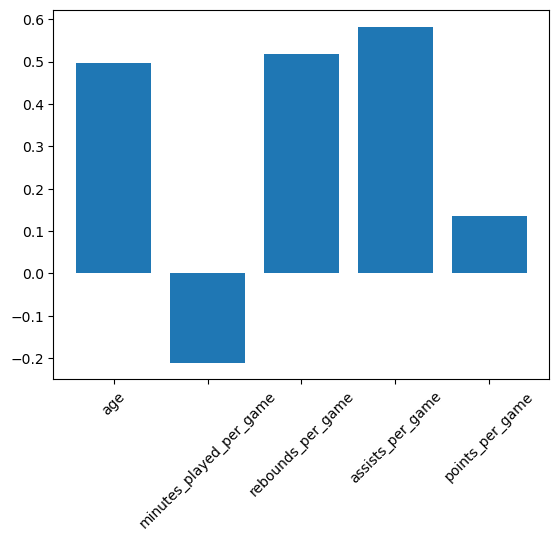

In [121]:
#Logistic Regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y)
print(log_reg.coef_)
import matplotlib.pyplot as plt
plt.bar(X.columns, log_reg.coef_[0])
plt.xticks(rotation=45)
plt.show()

[0.02435914 0.18949525 0.27664377 0.25787543 0.25162642]


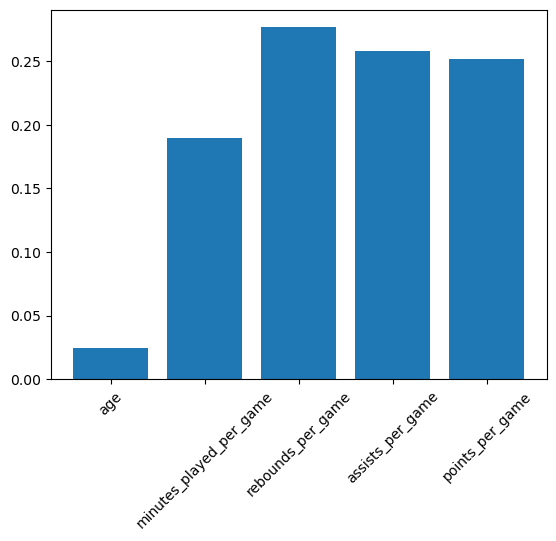

In [122]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_
feature_names = X_train.columns
print(feature_importances)
plt.bar(feature_names, feature_importances)
plt.xticks(rotation=45)
plt.show()

In the **Random Forest** model, the most important variables are "**Rebounds per game**", "**Assists per game**" and "**Points per game**".

In [34]:
# Correlation test among variables
X[var].corr(method='pearson')

NameError: name 'var' is not defined

High correlations between variables are observed, which may lead to multicollinearity and limit the interpretability of the model.

## Anomaly Case Study and Interpretation

### 1) Choose 3–5 anomaly players
To align with our SHAP local explanations, we choose the four
players that were explicitly listed as anomalies there:

1. Giannis Antetokounmpo
2. Damian Lillard
3. Tony Bradley
4. Nikola Jokić

### 2) SHAP Local Explanation

#### 2.1 What model SHAP is explaining here
In the notebook, we:

• used IsolationForest to create labels 𝑦(anomaly vs normal),

• trained a KNN classifier to predict those labels,

• then used SHAP KernelExplainer on KNN.

So SHAP is explaining:

“Which features made the surrogate KNN assign a higher anomaly-
class score for this player, consistent with the IsolationForest
labeling?”

This is useful because it tells you what pattern the anomaly labeling
corresponds to.

#### 2.2 How to read the SHAP waterfall

• Base value 𝐸[𝑓(𝑋)] ≈ 0.056: average anomaly-class score in
the background sample.

• Red/positive SHAP: pushes toward “more anomalous”.

• Blue/negative SHAP: pushes toward “more normal”.

• The right side 𝑓(𝑥)is the final anomaly-class score for that
player under the surrogate model.

### 3) Player-by-player case studies 
(SHAP → explanation → basketball
meaning)

### A) Giannis Antetokounmpo — “Superstar multi-category dominance” 

#### Values in SHAP plot

• Minutes: 32.1

• Points: 31.1

• Rebounds: 11.8

• Assists: 5.7

• Age: 28

#### SHAP local explanation (Main positive drivers (largest to smaller)):

• points_per_game = 31.1 (largest push toward anomaly)

• rebounds_per_game = 11.8

• age = 28

• assists_per_game = 5.7

• minutes_played_per_game = 32.1

#### Interpretation (why the model flags him)

• In a dataset of 50 players, 31 PPG is near the extreme right tail.

• Pairing that with ~12 RPG and ~6 APG is a rare combination
(high scorer + elite rebounder + meaningful playmaker).

• Isolation Forest and KNN both tend to treat “rare multi-
dimensional combinations” as anomalies.

#### Real-world basketball connection

• This profile matches a primary offensive engine who also
rebounds like a big and creates for others.

• In actual games: high points come from high usage (finishing at rim, transition, drawing fouls), rebounds from playing near the paint and defensive activity, assists from collapsing the defense and kicking out.

#### Why this is not a “real” outlier

• These numbers are plausible and common for MVP-level
seasons—rare, yes, but not erroneous.

• He’s an “elite tail” example: statistically unusual because he
is legitimately exceptional.

### B) Nikola Jokić — “Playmaking center archetype (rare combo: high rebounds + very high assists)”

#### Values in SHAP plot

• Minutes: 33.7

• Points: 24.5

• Rebounds: 11.8

• Assists: 9.8

• Age: 27

#### SHAP local explanation

Main positive drivers:

• rebounds_per_game = 11.8

• points_per_game = 24.5

• assists_per_game = 9.8

• smaller positives: minutes and age

#### Interpretation (why the model flags him)

• 11.8 RPG is elite.

• 9.8 APG is elite for anyone, and extremely rare for a center/big.

• The joint pattern (elite rebounds + elite assists + strong scoring) is exactly what multivariate anomaly detectors catch. Real-world basketball connection

• In-game, this corresponds to an offense that runs through a big as a hub: handoffs, high-post passing, short-roll reads.

• Assists are high because teammates’ shots are created directly from his decisions, not because of random variation.

#### Why this is not a “real” outlier
• Again: rare does not mean wrong. This is a known player archetype (the “point center”) at an extreme level. These centers function as offensive hubs, often operating from the top of the key or elbow to facilitate, similar to point guards, while still dominating the paint.

### C) Damian Lillard — “Extreme scoring guard (high PPG + high playmaking load)”

#### Values in SHAP plot

• Minutes: 36.3

• Points: 32.2

• Rebounds: 4.8

• Assists: 7.3

• Age: 32

### SHAP local explanation

• Strong positive drivers:

    • points_per_game = 32.2
    • age = 32

• Negative/offsetting drivers: 

    • minutes_played_per_game = 36.3 (pushed slightly toward normal in the plot)
    • rebounds_per_game = 4.8 (slightly toward normal)

• Small positive:

    • assists_per_game = 7.3

#### Interpretation (why the model flags him)

• 32.2 PPG is at the extreme right tail.

• Age being a contributor makes sense because high production
at an older age can be rarer in small samples (depends on who
else is in the dataset).

• Rebounds are normal for a guard, so they don’t contribute to
anomaly much.

#### Real-world basketball connection

• This is a classic “high-usage lead guard” box-score signature:

    • high points from shot volume + free throws + deep shooting gravity,

    • high assists from primary ball-handling responsibility,

    • rebounds are moderate/low because guards rebound less than bigs,

    • high minutes because the team keeps its offensive engine on the floor.

#### Why this is not a “real” outlier

• It’s not an impossible line; it reflects a legitimate offensive
role.

• He is “anomalous” only relative to a dataset where most
players are not asked to carry that scoring load.

### D) Tony Bradley — “Low-minute bench profile (contextual anomaly caused by role/playing time)”

#### Values in SHAP plot

• Minutes: 2.8

• Points: 1.6

• Rebounds: 0.9

• Assists: 0.1

• Age: 25

#### SHAP local explanation

• Biggest positive driver:

    • minutes_played_per_game = 2.8 (largest push toward
    anomaly)
• Smaller positive:
    • points_per_game = 1.6
    
• Slight negatives:

    • rebounds, age (small effects)
    • assists ~0 contribution
    
#### Interpretation (why the model flags him)

• 2.8 minutes per game is extremely low compared to most players in the 50-player sample.

• Very low minutes mechanically leads to low per-game points/rebounds/assists.

• Multivariate detectors often flag these “near-zero across many stats” points because they sit far from the typical cluster of rotation players. 

#### Real-world basketball connection

• This is what you see for:

    • end-of-bench players,
    • players on two-way/limited roles,
    • players who appeared in only a few games,
    • injury/rotation situations (not claiming that happened here—just the common causes).
    
#### Why this is not a “real” outlier

• It’s a role/context effect, not a data error.

• If you included more context—especially games played and/or used per-36 or per-possessions rates—this point would be less “mysterious.”

• In other words: he is a contextual anomaly because the feature set does not distinguish “low opportunity” from “low ability”.

### 4) Explaining the x-variables selected in further investigation (Rebounds & Assists)

We used surrogate classifiers (Logistic Regression + Random Forest) trained to predict the anomaly labels produced by Isolation Forest / LOF.

### 4.1 What the surrogate models said

#### Logistic Regression coefficients (after MinMax scaling)

• age: +0.4957

• minutes: −0.2104

• rebounds: +0.5185

• assists: +0.5830

• points: +0.1355

#### Interpretation:

• Larger positive coefficient ⇒ higher feature value tends to
increase “anomaly” likelihood.

• Assists and rebounds are the strongest positive terms here.

#### Random Forest feature importances

• age: 0.024

• minutes: 0.189

• rebounds: 0.277

• assists: 0.258

• points: 0.252

#### Interpretation:
• RF spreads importance across correlated features, but rebounds + assists + points dominate; age is least useful.

### 4.2 Why rebounds (RPG) and assists (APG) are especially good “anomaly separators”

#### Basketball meaning:

• Rebounds per game (RPG) is strongly tied to:

    • position/role (bigs rebound more),
    • time near rim, physicality,
    • team defensive scheme (boxing out, etc.).
    
• Assists per game (APG) is strongly tied to:
    
    • being a primary/secondary creator,
    • ball dominance and decision-making responsibility,
    • team offense running through you.
    
Key point: the combination of high RPG and high APG is relatively
rare.

• Many players have high RPG (traditional centers) but not high APG.

• Many players have high APG (point guards) but not high RPG.

• Players who do both (e.g., Jokić; sometimes Giannis-like point- forward usage) become multivariate anomalies.

This is exactly the kind of “joint abnormality” which the original IQR
method could not capture.

### 5) Connecting everything to the real-world game (and “why they’re not real outliers”)

### 5.1 Why univariate outlier rules failed (IQR)

The IQR test checks each feature separately. But basketball

performance is multidimensional and role-based:

• A player can be “not extreme” in any single stat, but still be rare
in the combination.

• Example pattern: high assists + high rebounds together (rare archetype) might not trip IQR thresholds individually.

So IQR answers: “Is this stat extreme by itself?”

But you needed: “Is this player profile unusual?”

### 5.2 Why Isolation Forest / LOF flagged these players

These models answer: “Is this point in a sparse region of the feature
space?”

They will highlight:

1. Elite multi-category stars (Giannis, Jokić, Lillard)
2. Extremely low-minute/low-stat profiles (Tony Bradley)
   
These are “rare,” but that rarity is structural in basketball:

• the league always has a small number of superstars,

• and always has bench players with tiny minutes.

### 5.3 The core argument: “Anomaly ≠ error”

#### A. Plausibility check (data quality)

• Are the values physically/biologically plausible? Yes (no
impossible stats).

• Are they consistent with known ranges of NBA per-game
outcomes? Yes.

#### B. Role/Context check

• Superstars: high usage + high minutes + elite production → rare
but expected.

• Bench players: low minutes → low counting stats → rare in a
sample dominated by rotation players.

#### C. Sampling & threshold check

• With only 50 players, and contamination set to 0.05–0.10, the
algorithm is forced to label ~3–5 players as anomalies even if
the dataset is perfectly valid.

• So “someone must be an anomaly” is partly a modeling choice,
not necessarily a real phenomenon.

#### D. “Contextual anomaly” explanation

• They are outliers relative to the mixed group (guards, bigs,
starters, bench all together).

• If you re-run detection within subgroups (by
position/role/minutes tier), many of these would stop being
“anomalies.”

## Conclusion

In this study, we applied an anomaly detection model to identify players with statistically unusual performance profiles.
Using SHAP-based explanations, we found that rebounds per game consistently emerged as a key contributing factor in classifying players as anomalies.

However, further investigation revealed that rebounds alone do not fully explain the anomaly patterns.
Correlation analysis indicates that rebounds are moderately associated with other performance variables such as points and minutes played, suggesting that these factors tend to co-occur rather than act independently.

Therefore, while rebounds appear to be the most influential variable in the model’s decision-making process, it would be inappropriate to conclude that other variables have no meaningful impact.
Instead, anomalous players are better characterized by a combination of high rebounds and complementary performance metrics, rather than a single dominant statistic.

To assess the robustness of our findings, we examined multiple threshold values for anomaly classification.
Although the number of identified anomalous players varied across thresholds, the relative importance of rebounds and the overall interpretation of anomalous profiles remained consistent.

Overall, our findings highlight the importance of combining model-based explanations with additional statistical analysis to avoid oversimplified interpretations of variable importance.